mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8736999999880791 seconds
All requested packages already installed.
Dataset:
 [24.5  24.7  25.6  25.   24.7  23.3  23.3  24.   25.1  24.3  23.3  24.1
 24.1  24.2  25.2  24.9  24.7  24.1  25.   24.7  24.9  25.   24.   23.98
 24.3  24.2  24.56 24.5  24.7 ]

Sample Size : 29
Sample Mean : 24.4462
Sample Std  : 0.5695

--- One Sample Z-Test ---
H0: μ = 25.0  |  H1: μ ≠ 25.0
Z-statistic : -5.237
Z-critical  : ±1.96
P-value     : 0.0
Result      : Reject H0

--- One Sample T-Test ---
H0: μ = 25.0  |  H1: μ ≠ 25.0
T-statistic : -5.237
T-critical  : ±2.0484
P-value     : 0.0
Result      : Reject H0

--- Independent Sample T-Test ---
H0: μ1 = μ2  |  H1: μ1 ≠ μ2
Group1 Mean : 24.36  |  Group2 Mean : 24.5386
T-statistic : -0.8394
P-value     : 0.4086
Result      : Fail to Reject H0

--- Paired Sample T-Test ---
H

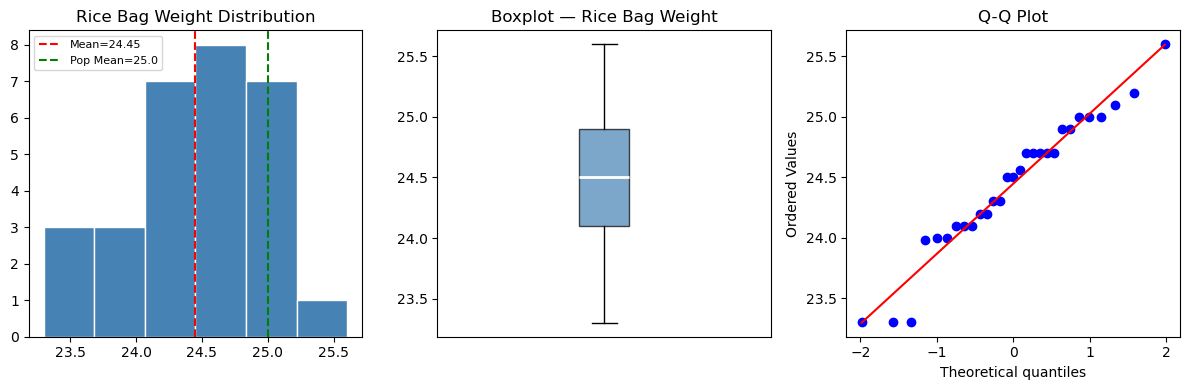

In [2]:
%matplotlib inline
!mamba install pandas matplotlib numpy scipy
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('exp3_RelianceDataMart.csv')
data = df['Rice_Bag_Weight']

print("Dataset:\n", data.values)
print("\nSample Size :", len(data))
print("Sample Mean :", round(data.mean(), 4))
print("Sample Std  :", round(data.std(), 4))

pop_mean = 25.0
alpha = 0.05

print("\n--- One Sample Z-Test ---")
z_stat = (data.mean() - pop_mean) / (data.std() / np.sqrt(len(data)))
z_crit = 1.96
p_val_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print(f"H0: μ = {pop_mean}  |  H1: μ ≠ {pop_mean}")
print(f"Z-statistic : {round(z_stat, 4)}")
print(f"Z-critical  : ±{z_crit}")
print(f"P-value     : {round(p_val_z, 4)}")
print("Result      :", "Reject H0" if p_val_z < alpha else "Fail to Reject H0")

print("\n--- One Sample T-Test ---")
t_stat, p_val_t = stats.ttest_1samp(data, pop_mean)
t_crit = stats.t.ppf(1 - alpha/2, df=len(data)-1)
print(f"H0: μ = {pop_mean}  |  H1: μ ≠ {pop_mean}")
print(f"T-statistic : {round(t_stat, 4)}")
print(f"T-critical  : ±{round(t_crit, 4)}")
print(f"P-value     : {round(p_val_t, 4)}")
print("Result      :", "Reject H0" if p_val_t < alpha else "Fail to Reject H0")

print("\n--- Independent Sample T-Test ---")
group1 = data[:15]
group2 = data[15:]
t2, p2 = stats.ttest_ind(group1, group2)
print("H0: μ1 = μ2  |  H1: μ1 ≠ μ2")
print(f"Group1 Mean : {round(group1.mean(), 4)}  |  Group2 Mean : {round(group2.mean(), 4)}")
print(f"T-statistic : {round(t2, 4)}")
print(f"P-value     : {round(p2, 4)}")
print("Result      :", "Reject H0" if p2 < alpha else "Fail to Reject H0")

print("\n--- Paired Sample T-Test ---")
np.random.seed(42)
before = data.values
after  = before + np.random.uniform(-0.5, 0.5, size=len(before))
t3, p3 = stats.ttest_rel(before, after)
print("H0: μ_before = μ_after  |  H1: μ_before ≠ μ_after")
print(f"T-statistic : {round(t3, 4)}")
print(f"P-value     : {round(p3, 4)}")
print("Result      :", "Reject H0" if p3 < alpha else "Fail to Reject H0")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(data, bins=6, color='steelblue', edgecolor='white')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean={data.mean():.2f}')
plt.axvline(pop_mean, color='green', linestyle='--', label=f'Pop Mean={pop_mean}')
plt.title('Rice Bag Weight Distribution')
plt.legend(fontsize=8)

plt.subplot(1, 3, 2)
plt.boxplot(data, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='white', linewidth=2))
plt.title('Boxplot — Rice Bag Weight')
plt.xticks([])

plt.subplot(1, 3, 3)
stats.probplot(data, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()